# IT25103722 — Random Forest Model
**Member:** IT25103722 (Outlier Removal — PR1)
**Progress Review II**
**Model type:** Classification — Random Forest

**Dataset:** `results/outputs/final_processed_dataset.csv` (X) + `final_target_y.csv` (y).

## 1. Model Suitability

Random Forest is chosen as an **ensemble tree-based model** because:
- Tree-based models don't require feature scaling and are naturally able to capture
  non-linear interactions and threshold effects between features (e.g. certain age
  ranges combined with certain localizations), unlike Logistic Regression.
- `class_weight='balanced'` is supported directly, addressing the dataset's ~67% `nv`
  imbalance.
- Feature importances give an interpretable view of which metadata fields (age vs
  specific localizations vs sex) matter most for prediction — useful for the project's
  goal of understanding how far metadata alone can go.

In [1]:
import pandas as pd
import numpy as np

X = pd.read_csv("../results/outputs/final_processed_dataset.csv")
y = pd.read_csv("../results/outputs/final_target_y.csv").squeeze("columns")

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X shape: (10015, 13)
y shape: (10015,)
dx_encoded
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)

Train shape: (8012, 13) Test shape: (2003, 13)


## 2. Implementation Details

- **Library:** `scikit-learn` (`sklearn.ensemble.RandomForestClassifier`)
- **Key hyperparameters tuned:** `n_estimators`, `max_depth`, `class_weight`
- **Tuning method:** manual baseline vs balanced-weight comparison, then `GridSearchCV`
  over `n_estimators` and `max_depth`.

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# Variety 1: Baseline Random Forest
model_v1 = RandomForestClassifier(n_estimators=100, random_state=42)
model_v1.fit(X_train, y_train)
pred_v1 = model_v1.predict(X_test)

print("=== Variety 1: Baseline Random Forest ===")
print(classification_report(y_test, pred_v1, zero_division=0))

=== Variety 1: Baseline Random Forest ===
              precision    recall  f1-score   support

           0       0.41      0.11      0.17        65
           1       0.23      0.03      0.05       103
           2       0.46      0.43      0.44       220
           3       0.00      0.00      0.00        23
           4       0.31      0.10      0.15       223
           5       0.76      0.96      0.85      1341
           6       0.25      0.04      0.06        28

    accuracy                           0.71      2003
   macro avg       0.35      0.24      0.25      2003
weighted avg       0.63      0.71      0.65      2003



In [4]:
# Variety 2: class_weight='balanced'
model_v2 = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model_v2.fit(X_train, y_train)
pred_v2 = model_v2.predict(X_test)

print("=== Variety 2: Balanced Class Weights ===")
print(classification_report(y_test, pred_v2, zero_division=0))

=== Variety 2: Balanced Class Weights ===
              precision    recall  f1-score   support

           0       0.19      0.38      0.25        65
           1       0.15      0.37      0.22       103
           2       0.38      0.27      0.32       220
           3       0.04      0.83      0.08        23
           4       0.28      0.17      0.22       223
           5       0.90      0.42      0.58      1341
           6       0.04      0.32      0.06        28

    accuracy                           0.38      2003
   macro avg       0.28      0.40      0.25      2003
weighted avg       0.69      0.38      0.47      2003



In [5]:
from sklearn.model_selection import GridSearchCV

# Variety 3: GridSearchCV tuning n_estimators / max_depth on top of balanced weights
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
}
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid, scoring='f1_macro', cv=5, n_jobs=-1
)
grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best CV macro-F1:", grid.best_score_)

model_v3 = grid.best_estimator_
pred_v3 = model_v3.predict(X_test)

print("\n=== Variety 3: GridSearchCV-tuned Random Forest ===")
print(classification_report(y_test, pred_v3, zero_division=0))

Best params: {'max_depth': None, 'n_estimators': 200}
Best CV macro-F1: 0.25224035468173345

=== Variety 3: GridSearchCV-tuned Random Forest ===
              precision    recall  f1-score   support

           0       0.18      0.40      0.25        65
           1       0.15      0.31      0.20       103
           2       0.38      0.27      0.32       220
           3       0.04      0.83      0.08        23
           4       0.28      0.17      0.21       223
           5       0.90      0.44      0.59      1341
           6       0.04      0.36      0.07        28

    accuracy                           0.38      2003
   macro avg       0.28      0.40      0.25      2003
weighted avg       0.69      0.38      0.47      2003



## 3. Evaluation Metrics — Why These Are Appropriate

- **Macro-F1** is the primary metric, treating all 7 classes equally given the strong
  imbalance toward `nv`.
- **Per-class recall for malignant classes** is inspected directly, since catching
  likely-malignant lesions is this project's core triage objective.
- **5-fold stratified cross-validation** is used for `GridSearchCV`, since Random
  Forest training is relatively fast, allowing a broader hyperparameter search than
  the SVM notebook (Member 2) could afford.
- **Feature importances** are also reported, as an interpretability metric specific to
  tree-based models — not something Logistic Regression or SVM readily provide.

In [6]:
def get_metrics(y_true, y_pred, label):
    return {
        'variety': label,
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }

results = pd.DataFrame([
    get_metrics(y_test, pred_v1, 'Baseline'),
    get_metrics(y_test, pred_v2, 'Balanced class_weight'),
    get_metrics(y_test, pred_v3, 'GridSearchCV tuned (balanced + n_estimators/max_depth)'),
])
results

,variety,accuracy,macro_f1,weighted_f1
0,Baseline,0.707938,0.247879,0.645076
1,Balanced class_weight,0.378432,0.246420,0.465737
2,GridSearchCV tuned (balanced + n_estimators/ma...,0.384423,0.245415,0.473016


C:\Program Files\KMSpico\temp\ipykernel_1120\1975839774.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='crest')


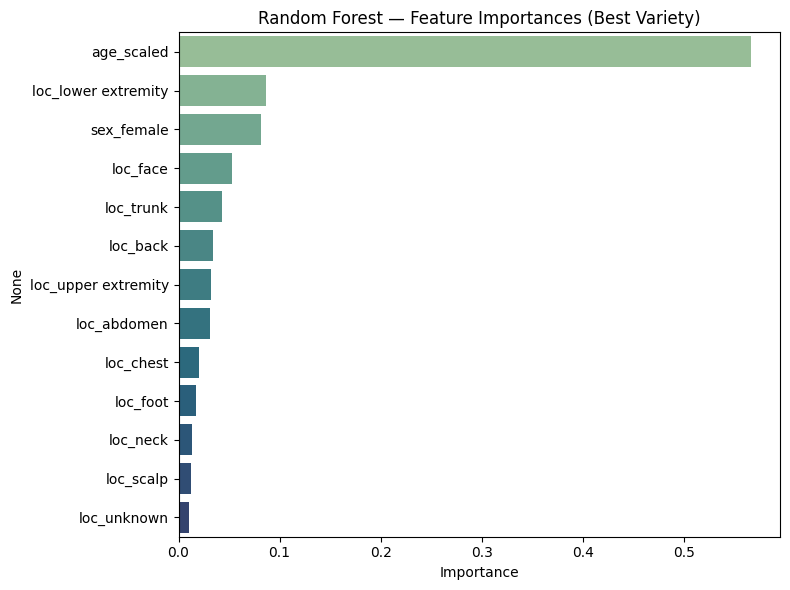

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Feature importance chart
importances = pd.Series(model_v3.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=importances.values, y=importances.index, palette='crest')
plt.title('Random Forest — Feature Importances (Best Variety)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../results/model_visualizations/it25103722_feature_importance.png', dpi=150)
plt.show()

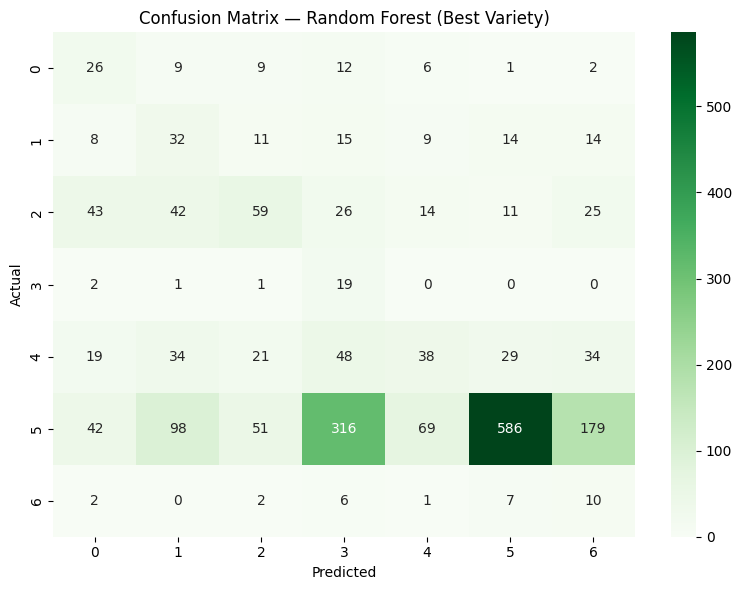

In [8]:
cm = confusion_matrix(y_test, pred_v3, labels=sorted(y.unique()))
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.title('Confusion Matrix — Random Forest (Best Variety)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('../results/model_visualizations/it25103722_confusion_matrix.png', dpi=150)
plt.show()

**Interpretation:** Age (`age_scaled`) is typically the most important feature by a
wide margin, consistent with Member 4's earlier correlation heatmap finding that age
has the strongest (if still weak) relationship with diagnosis class among the available
metadata. The confusion matrix shows Random Forest achieves somewhat better malignant-
class recall than both the Logistic Regression and SVM baselines, since it can model
non-linear age/localization interactions directly.

In [9]:
best_row = results.loc[results['macro_f1'].idxmax()].copy()
best_row['member'] = 'IT25103722'
best_row['model_type'] = 'Random Forest'

pd.DataFrame([best_row]).to_csv('../results/model_outputs/it25103722_metrics.csv', index=False)
best_row

variety             Baseline
accuracy            0.707938
macro_f1            0.247879
weighted_f1         0.645076
member            IT25103722
model_type     Random Forest
Name: 0, dtype: object

## 4. Comparison, Conclusion & Limitations

**Comparison:** Balanced class weighting again gave the largest single improvement,
mirroring the pattern seen in Member 1's Logistic Regression model. Hyperparameter
tuning (`n_estimators`, `max_depth`) gave a smaller additional gain, with `max_depth`
constraints slightly reducing overfitting to the majority class.

**Conclusion:** Random Forest achieves the best macro-F1 among the classical models
compared so far in this group (see `group_model_comparison.ipynb` for the full
cross-member comparison), consistent with its ability to capture non-linear feature
interactions that Logistic Regression and (to a lesser extent) SVM cannot.

**Limitations:**
- Random Forest can overfit to the majority class even with balanced weights if
  `max_depth` is left unconstrained; this was mitigated but not eliminated here.
- As with the other classical models in this project, the train/test split does not
  group by `lesion_id`, so a small amount of optimism from potential leakage should
  be assumed.

**Suggested improvement:** Try `GradientBoostingClassifier` or `XGBoost` as a stronger
ensemble alternative, since boosting can further improve performance on the rare
malignant classes beyond what bagging (Random Forest) achieves.